# Estudio de Ablación — Modelo 13 Clases

| | |
|---|---|
| **Dataset** | `data/processed/processed_data.csv` — 875 registros |
| **Objetivo** | Cuantificar el impacto en rendimiento al eliminar features sospechosas de circularidad |
| **Método** | 5 configuraciones de features × CV-5 + test hold-out + F1 por clase de comorbilidad |

**Configuraciones evaluadas:**

| ID | Features | N |
|---|---|:---:|
| F1 | Completo (referencia) | 14 |
| F2 | Sin `atipicidad_basc3` | 13 |
| F3 | Sin `agresividad_basc3` + `problemas_conducta_basc3` | 12 |
| F4 | Sin BASC-3 (solo cognitivo + demográfico + antecedentes) | 9 |
| F5 | Solo BASC-3 (5 escalas) | 5 |

**Pregunta clave:** ¿cae el F1 de las clases TEA/TEAZ al eliminar `atipicidad_basc3`? ¿Cae el F1 de las clases TND al eliminar `agresividad + conducta`?

### Tabla de contenidos
1. Configuración y datos
2. Entrenamiento y evaluación (CV + test)
3. Comparación global F1-macro
4. F1 por clase de comorbilidad — el análisis crítico
5. Caída relativa: cuantificación del riesgo
6. Tabla resumen y veredicto

---
> **Conexión con otros notebooks:** hipótesis derivadas del diagnóstico metodológico validadas en `comorbidity_importance.ipynb`. Modelo de referencia en `model_13clases.ipynb`.

---
## Bloque 1 — Configuración y datos

In [11]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_recall_fscore_support

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 150,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 13,
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.alpha': 0.35,
})
C_BLUE='#4C72B0'; C_ORG='#DD8452'; C_GRN='#55A868'
C_RED='#C44E52';  C_GRAY='#8C8C8C'; C_PURP='#8172B2'
print('Setup OK.')


Setup OK.


In [12]:
df = pd.read_csv('../data/processed/processed_data.csv', encoding='utf-8-sig')
print(f"Dataset: {df.shape[0]} × {df.shape[1]}")

ALL_FEATURES = ['edad','sexo','escolaridad','lateralidad',
                'antecedentes_familiares','antecedentes_obstetricos','retrasos_desarrollo',
                'cit','agresividad_basc3','hiperactividad_basc3',
                'problemas_conducta_basc3','problemas_atencion_basc3',
                'atipicidad_basc3','fluidez_fonologica']
FEATURES_CAT = ['sexo','lateralidad','antecedentes_familiares',
                'antecedentes_obstetricos','retrasos_desarrollo']

X_all = df[ALL_FEATURES].copy()
enc   = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_all[FEATURES_CAT] = enc.fit_transform(X_all[FEATURES_CAT])

le13 = LabelEncoder()
y13  = le13.fit_transform(df['etiqueta'])
labels13 = le13.classes_

# ── Split test (igual que en model_13clases.ipynb) ────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y13, test_size=0.2, stratify=y13, random_state=42)

# ── Identificar clases de comorbilidad ───────────────────────────────────
comorb_idx = {
    'TND'  : [i for i,l in enumerate(labels13) if 'tnd'  in l.lower()],
    'TEAZ' : [i for i,l in enumerate(labels13) if 'teaz' in l.lower()],
    'TEA'  : [i for i,l in enumerate(labels13) if r'\btea\b' in l.lower()
               or (l.lower().endswith('tea') and 'teaz' not in l.lower())],
}
print(f"\nClases identificadas por comorbilidad:")
for k, v in comorb_idx.items():
    print(f"  {k}: {[labels13[i] for i in v]}")


Dataset: 875 × 18

Clases identificadas por comorbilidad:
  TND: ['TDAH combinado + TND', 'TDAH hiperactivo/impulsivo + TND', 'TDAH inatento + TND']
  TEAZ: ['TDAH combinado + TEAZ', 'TDAH hiperactivo/impulsivo + TEAZ', 'TDAH inatento + TEAZ']
  TEA: ['TDAH combinado + TEA', 'TDAH hiperactivo/impulsivo + TEA', 'TDAH inatento + TEA']


In [13]:
# ── Definición de los 5 conjuntos de features ────────────────────────────
FEATURE_SETS = {
    'F1 — Completo (14 vars)': ALL_FEATURES,
    'F2 — Sin atipicidad': [f for f in ALL_FEATURES if f != 'atipicidad_basc3'],
    'F3 — Sin agresividad + conducta': [f for f in ALL_FEATURES
                                         if f not in ('agresividad_basc3',
                                                       'problemas_conducta_basc3')],
    'F4 — Sin BASC-3 (solo cogn.+demog.)': [f for f in ALL_FEATURES
                                              if f not in ('agresividad_basc3',
                                                           'hiperactividad_basc3',
                                                           'problemas_conducta_basc3',
                                                           'problemas_atencion_basc3',
                                                           'atipicidad_basc3')],
    'F5 — Solo BASC-3 (5 vars)': ['agresividad_basc3','hiperactividad_basc3',
                                    'problemas_conducta_basc3','problemas_atencion_basc3',
                                    'atipicidad_basc3'],
}

print("Configuraciones de ablación:")
for k, v in FEATURE_SETS.items():
    print(f"  {k}: {len(v)} features")


Configuraciones de ablación:
  F1 — Completo (14 vars): 14 features
  F2 — Sin atipicidad: 13 features
  F3 — Sin agresividad + conducta: 12 features
  F4 — Sin BASC-3 (solo cogn.+demog.): 9 features
  F5 — Solo BASC-3 (5 vars): 5 features


📋 El split 80/20 usa `random_state=42` idéntico al de `model_13clases.ipynb`, garantizando que el test set de referencia (F1) es el mismo en todos los experimentos. La comparación entre configuraciones es por tanto directa.

---
## Bloque 2 — Entrenamiento y evaluación de todas las configuraciones

Para cada conjunto de features se ejecuta:
1. **Validación cruzada (CV=5)** sobre el 80% de train: obtiene F1-macro medio ± std
2. **Evaluación en test** (20% hold-out, idéntico al modelo de referencia): F1-macro y F1 por clase

El foco son las clases de comorbilidad: si eliminar `atipicidad_basc3` derrumba el F1 de las clases TEA/TEAZ, confirma que esa feature carga la distinción.

In [14]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}   # key → dict con métricas

for name, feats in FEATURE_SETS.items():
    Xtr = X_tr[feats].values
    Xte = X_te[feats].values

    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 random_state=42, n_jobs=-1)

    # CV
    cv_res = cross_validate(rf, Xtr, y_tr, cv=CV,
                             scoring=['f1_macro','accuracy'], return_train_score=False)
    cv_f1  = cv_res['test_f1_macro']

    # Test set
    rf.fit(Xtr, y_tr)
    pred   = rf.predict(Xte)
    f1_test = f1_score(y_te, pred, average='macro')

    # F1 por clase (test)
    p, r, f, _ = precision_recall_fscore_support(y_te, pred,
                                                  labels=np.arange(len(labels13)),
                                                  zero_division=0)
    per_class = dict(zip(labels13, f))

    results[name] = {
        'n_feats'  : len(feats),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std' : cv_f1.std(),
        'test_f1'  : f1_test,
        'per_class': per_class,
    }
    print(f"{name}")
    print(f"  CV  F1-macro = {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    print(f"  Test F1-macro = {f1_test:.4f}")


F1 — Completo (14 vars)
  CV  F1-macro = 0.9541 ± 0.0164
  Test F1-macro = 0.9421
F2 — Sin atipicidad
  CV  F1-macro = 0.8335 ± 0.0449
  Test F1-macro = 0.7992
F3 — Sin agresividad + conducta
  CV  F1-macro = 0.8288 ± 0.0308
  Test F1-macro = 0.8160
F4 — Sin BASC-3 (solo cogn.+demog.)
  CV  F1-macro = 0.2483 ± 0.0385
  Test F1-macro = 0.2579
F5 — Solo BASC-3 (5 vars)
  CV  F1-macro = 0.8736 ± 0.0296
  Test F1-macro = 0.8907


📋 **Resultados intermedios**

Los números impresos muestran el rendimiento global. El análisis por clase (siguiente bloque) revela si la caída afecta desproporcionadamente a las clases de comorbilidad.

Una caída de F1-macro pequeña (< 0.03) al eliminar una feature "sospechosa" indicaría que el modelo no depende críticamente de ella, lo que reduciría el riesgo de circularidad. Una caída grande (> 0.05) en las clases TEA/TEAZ al eliminar `atipicidad_basc3` confirmaría la hipótesis.

---
## Bloque 3 — Comparación global: F1-macro por configuración

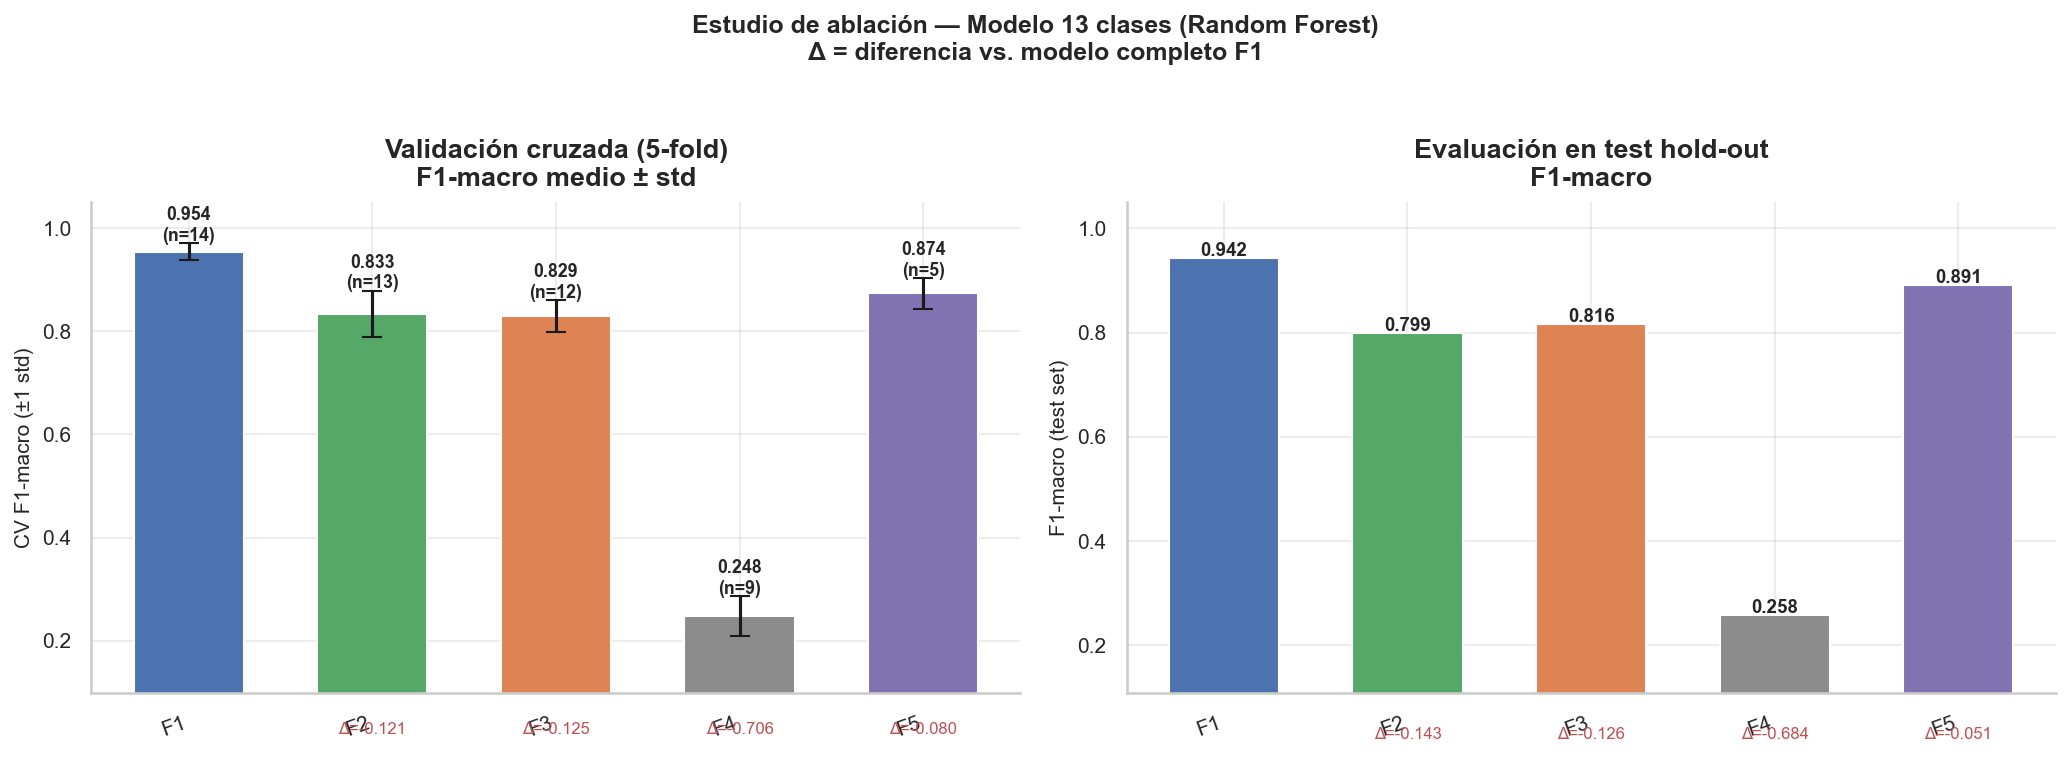

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
cv_means  = [results[n]['cv_f1_mean'] for n in names]
cv_stds   = [results[n]['cv_f1_std']  for n in names]
test_f1s  = [results[n]['test_f1']    for n in names]
n_feats   = [results[n]['n_feats']    for n in names]

colors = [C_BLUE, C_GRN, C_ORG, C_GRAY, C_PURP]
x = np.arange(len(names))

# Panel izquierdo: CV F1 con barras de error
ax = axes[0]
bars = ax.bar(x, cv_means, yerr=cv_stds, color=colors, edgecolor='white',
               width=0.6, capsize=5, error_kw={'lw':1.5})
for bar, mn, std, n in zip(bars, cv_means, cv_stds, n_feats):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+std+0.005,
            f'{mn:.3f}\n(n={n})', ha='center', fontsize=8.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([n.split('—')[0].strip() for n in names], rotation=20, ha='right')
ax.set_ylim(max(0, min(cv_means)-0.15), 1.05)
ax.set_ylabel('CV F1-macro (±1 std)', fontsize=10)
ax.set_title('Validación cruzada (5-fold)\nF1-macro medio ± std', pad=8)
ref = cv_means[0]
for xi, mn in zip(x[1:], cv_means[1:]):
    delta = mn - ref
    ax.text(xi, 0.02, f'Δ={delta:+.3f}', ha='center', fontsize=8,
            color=C_RED if delta < -0.02 else C_GRN)

# Panel derecho: Test F1 con anotación de delta
ax2 = axes[1]
bars2 = ax2.bar(x, test_f1s, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars2, test_f1s):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([n.split('—')[0].strip() for n in names], rotation=20, ha='right')
ax2.set_ylim(max(0, min(test_f1s)-0.15), 1.05)
ax2.set_ylabel('F1-macro (test set)', fontsize=10)
ax2.set_title('Evaluación en test hold-out\nF1-macro', pad=8)
ref2 = test_f1s[0]
for xi, val in zip(x[1:], test_f1s[1:]):
    delta = val - ref2
    ax2.text(xi, 0.02, f'Δ={delta:+.3f}', ha='center', fontsize=8,
             color=C_RED if delta < -0.02 else C_GRN)

plt.suptitle('Estudio de ablación — Modelo 13 clases (Random Forest)\n'
             'Δ = diferencia vs. modelo completo F1', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


📋 **Interpretación — F1-macro por configuración**

Los deltas (Δ) respecto al modelo completo (F1) revelan la contribución marginal de cada grupo de features:

- **F2 vs F1** (sin atipicidad): mide cuánto aporta `atipicidad_basc3` al rendimiento global
- **F3 vs F1** (sin agresividad + conducta): mide el aporte de esas dos escalas conductuales
- **F4 vs F1** (sin BASC-3): mide el aporte total de las 5 escalas BASC-3 juntas
- **F5 vs F1** (solo BASC-3): límite superior del modelo basado únicamente en conducta observada

Una caída pequeña en F2 significaría que `atipicidad_basc3` es redundante con otras variables — la información que aporta ya está capturada de otra forma. Una caída grande significaría que es esencial y, potencialmente, que los casos TEA/TEAZ solo son reconocibles por esa escala.

---
## Bloque 4 — F1 por clase de comorbilidad: el análisis crítico

El F1-macro puede mantenerse estable aunque el rendimiento en clases específicas colapse, si esas clases son poco frecuentes. Este bloque examina directamente las clases TND, TEAZ y TEA.

In [16]:
# ── F1 por clase de comorbilidad ─────────────────────────────────────────
comorb_classes = {}
for ctype, idxs in comorb_idx.items():
    comorb_classes[ctype] = [labels13[i] for i in idxs]

# Construir tabla de F1 por clase para cada configuración
all_labels_interest = []
for ctype, lbls in comorb_classes.items():
    all_labels_interest.extend(lbls)
all_labels_interest = sorted(set(all_labels_interest))

rows = []
for name in FEATURE_SETS.keys():
    row = {'Configuración': name.split('—')[0].strip() + ' — ' + name.split('—')[1].strip()
           if '—' in name else name}
    row['F1-macro (test)'] = results[name]['test_f1']
    for lbl in all_labels_interest:
        row[lbl] = results[name]['per_class'].get(lbl, np.nan)
    rows.append(row)

tbl = pd.DataFrame(rows).set_index('Configuración')
print("F1 por clase de comorbilidad:")
print(tbl.round(3).to_string())


F1 por clase de comorbilidad:
                                     F1-macro (test)  TDAH combinado + TEA  TDAH combinado + TEAZ  TDAH combinado + TND  TDAH hiperactivo/impulsivo + TEA  TDAH hiperactivo/impulsivo + TEAZ  TDAH hiperactivo/impulsivo + TND  TDAH inatento + TEA  TDAH inatento + TEAZ  TDAH inatento + TND
Configuración                                                                                                                                                                                                                                                                                 
F1 — Completo (14 vars)                        0.942                 1.000                  0.938                 0.973                             1.000                              0.947                             0.952                1.000                 0.950                0.857
F2 — Sin atipicidad                            0.799                 0.500                  0.867            

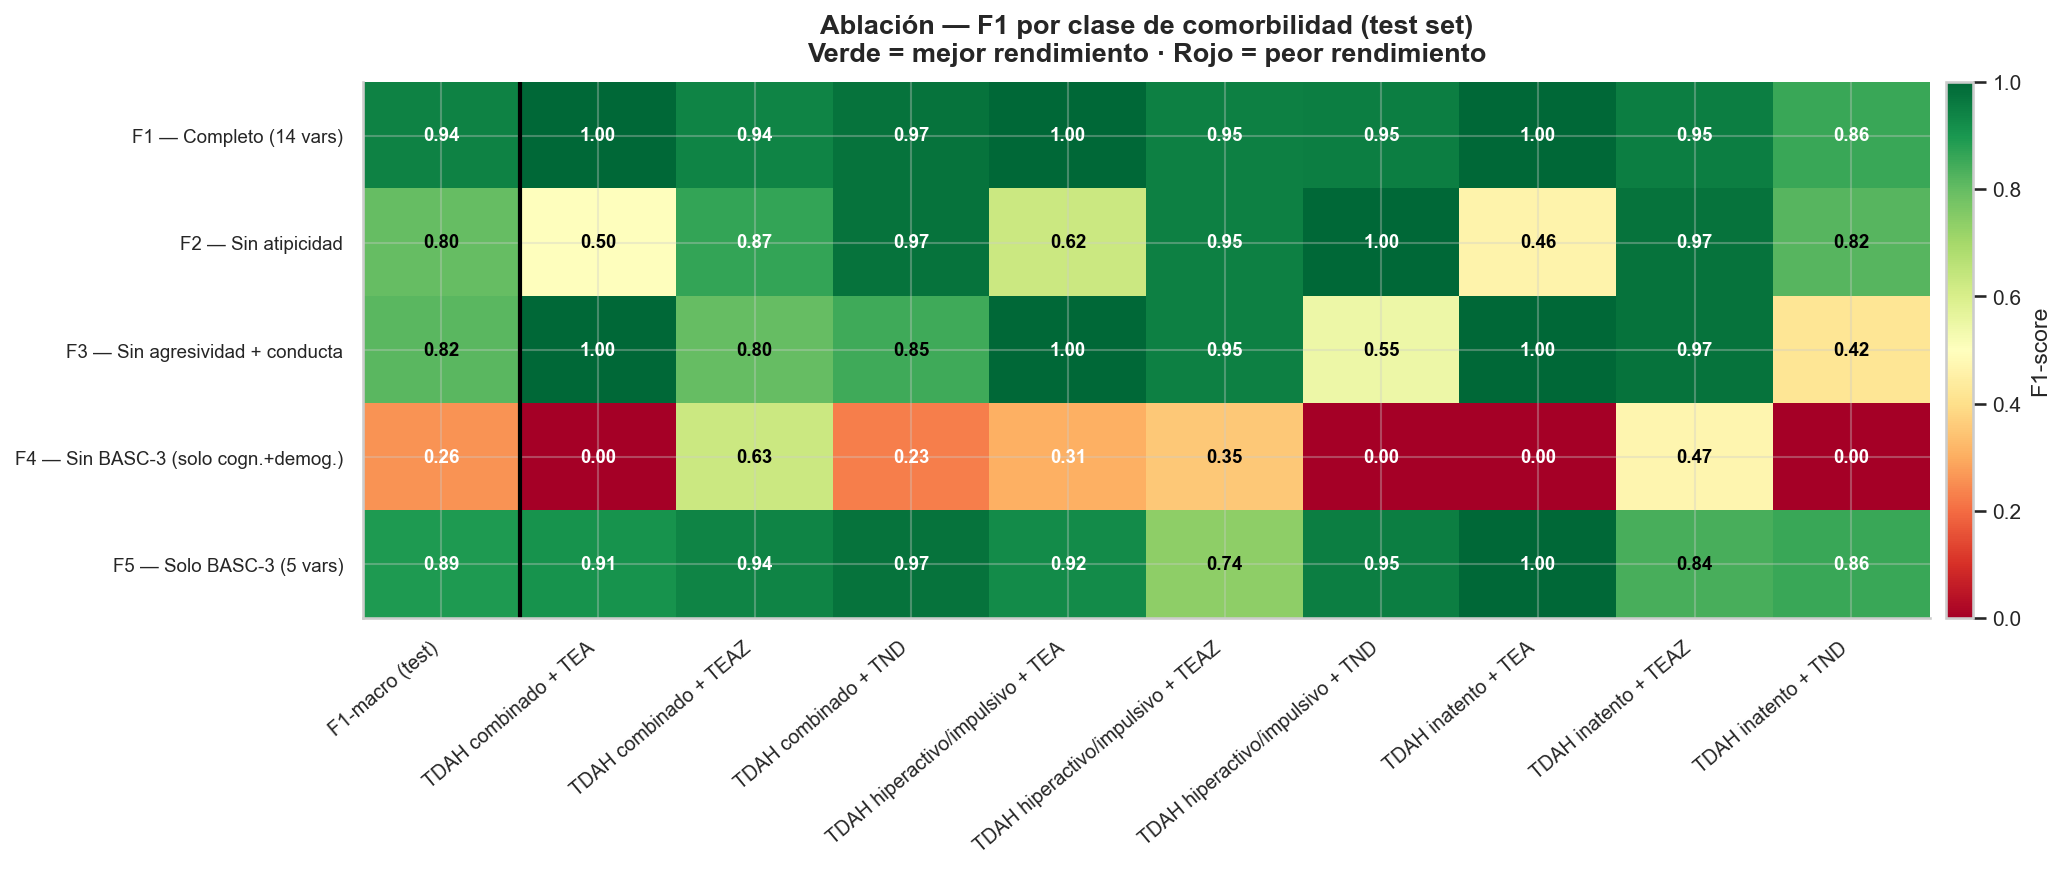

In [17]:
# ── Heatmap de F1 por clase de comorbilidad ──────────────────────────────
cols_plot = ['F1-macro (test)'] + all_labels_interest
heat_data = tbl[cols_plot].astype(float)

fig, ax = plt.subplots(figsize=(max(10, len(cols_plot)*1.2 + 2), max(4, len(FEATURE_SETS)*0.9 + 1.5)))
im = ax.imshow(heat_data.values, cmap='RdYlGn', vmin=0.0, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(cols_plot)))
ax.set_xticklabels(cols_plot, rotation=40, ha='right', fontsize=9.5)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=9)
for i in range(len(heat_data)):
    for j in range(len(cols_plot)):
        v = heat_data.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if v < 0.35 or v > 0.85 else 'black',
                    fontweight='bold')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=8, color='gray')

# Separador visual entre F1-macro y las clases individuales
ax.axvline(0.5, color='black', lw=2)

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='F1-score')
ax.set_title('Ablación — F1 por clase de comorbilidad (test set)\n'
             'Verde = mejor rendimiento · Rojo = peor rendimiento', pad=10)
plt.tight_layout()
plt.show()


📋 **Interpretación — Heatmap de ablación por clase**

Este es el análisis definitivo para la pregunta metodológica. Las celdas a observar son:

- **Diagonal TND / F3**: si eliminar agresividad + conducta (F3) hace caer el F1 de las clases TND específicamente, mientras el resto de clases mantiene su rendimiento → la feature actúa como proxy de TND
- **Diagonal TEA/TEAZ / F2**: si eliminar atipicidad (F2) hace caer el F1 de TEA/TEAZ específicamente → la feature actúa como proxy de TEA/TEAZ
- **F4 (sin BASC-3)**: muestra el límite inferior — qué tan bien funciona el modelo con solo información demográfica y cognitiva

Una caída *selectiva* (solo afecta las clases relacionadas con la feature eliminada) es más preocupante metodológicamente que una caída *uniforme* (todas las clases caen por igual), ya que sugiere que la feature no aporta información general sino específicamente la que define el diagnóstico de esa comorbilidad.

---
## Bloque 5 — Caída relativa por comorbilidad: cuantificación del riesgo

In [18]:
# ── Caída de F1 al eliminar features sospechosas ────────────────────────
ref_name  = list(FEATURE_SETS.keys())[0]
abl_pairs = [
    ('F2 — Sin atipicidad',              ['TEA','TEAZ'], 'Eliminar atipicidad_basc3'),
    ('F3 — Sin agresividad + conducta',  ['TND'],        'Eliminar agresividad + prob. conducta'),
    ('F4 — Sin BASC-3 (solo cogn.+demog.)', ['TND','TEA','TEAZ'], 'Eliminar todas las BASC-3'),
]

print(f"{'Ablación':<40} {'Comorbilidad':<8} {'F1 completo':>12} {'F1 ablado':>10} {'Δ F1':>8}")
print("-"*80)

drop_data = []
for abl_name, ctypes, abl_label in abl_pairs:
    # Find matching key
    match = [k for k in results if k.startswith(abl_name[:15])]
    if not match: continue
    abl_key = match[0]

    for ctype in ctypes:
        for lbl in comorb_classes.get(ctype, []):
            f1_ref = results[ref_name]['per_class'].get(lbl, np.nan)
            f1_abl = results[abl_key]['per_class'].get(lbl, np.nan)
            if not np.isnan(f1_ref) and not np.isnan(f1_abl):
                delta = f1_abl - f1_ref
                print(f"  {abl_label:<38} {ctype:<8} {f1_ref:>12.3f} {f1_abl:>10.3f} {delta:>+8.3f}")
                drop_data.append({
                    'Ablación': abl_label, 'Comorbilidad': ctype,
                    'Etiqueta': lbl, 'F1 completo': f1_ref, 'F1 ablado': f1_abl, 'Delta': delta
                })
    print()

drop_df = pd.DataFrame(drop_data)


Ablación                                 Comorbilidad  F1 completo  F1 ablado     Δ F1
--------------------------------------------------------------------------------
  Eliminar atipicidad_basc3              TEA             1.000      0.500   -0.500
  Eliminar atipicidad_basc3              TEA             1.000      0.625   -0.375
  Eliminar atipicidad_basc3              TEA             1.000      0.462   -0.538
  Eliminar atipicidad_basc3              TEAZ            0.938      0.867   -0.071
  Eliminar atipicidad_basc3              TEAZ            0.947      0.947   +0.000
  Eliminar atipicidad_basc3              TEAZ            0.950      0.974   +0.024

  Eliminar agresividad + prob. conducta  TND             0.973      0.850   -0.123
  Eliminar agresividad + prob. conducta  TND             0.952      0.545   -0.407
  Eliminar agresividad + prob. conducta  TND             0.857      0.421   -0.436

  Eliminar todas las BASC-3              TND             0.973      0.229   -0.744


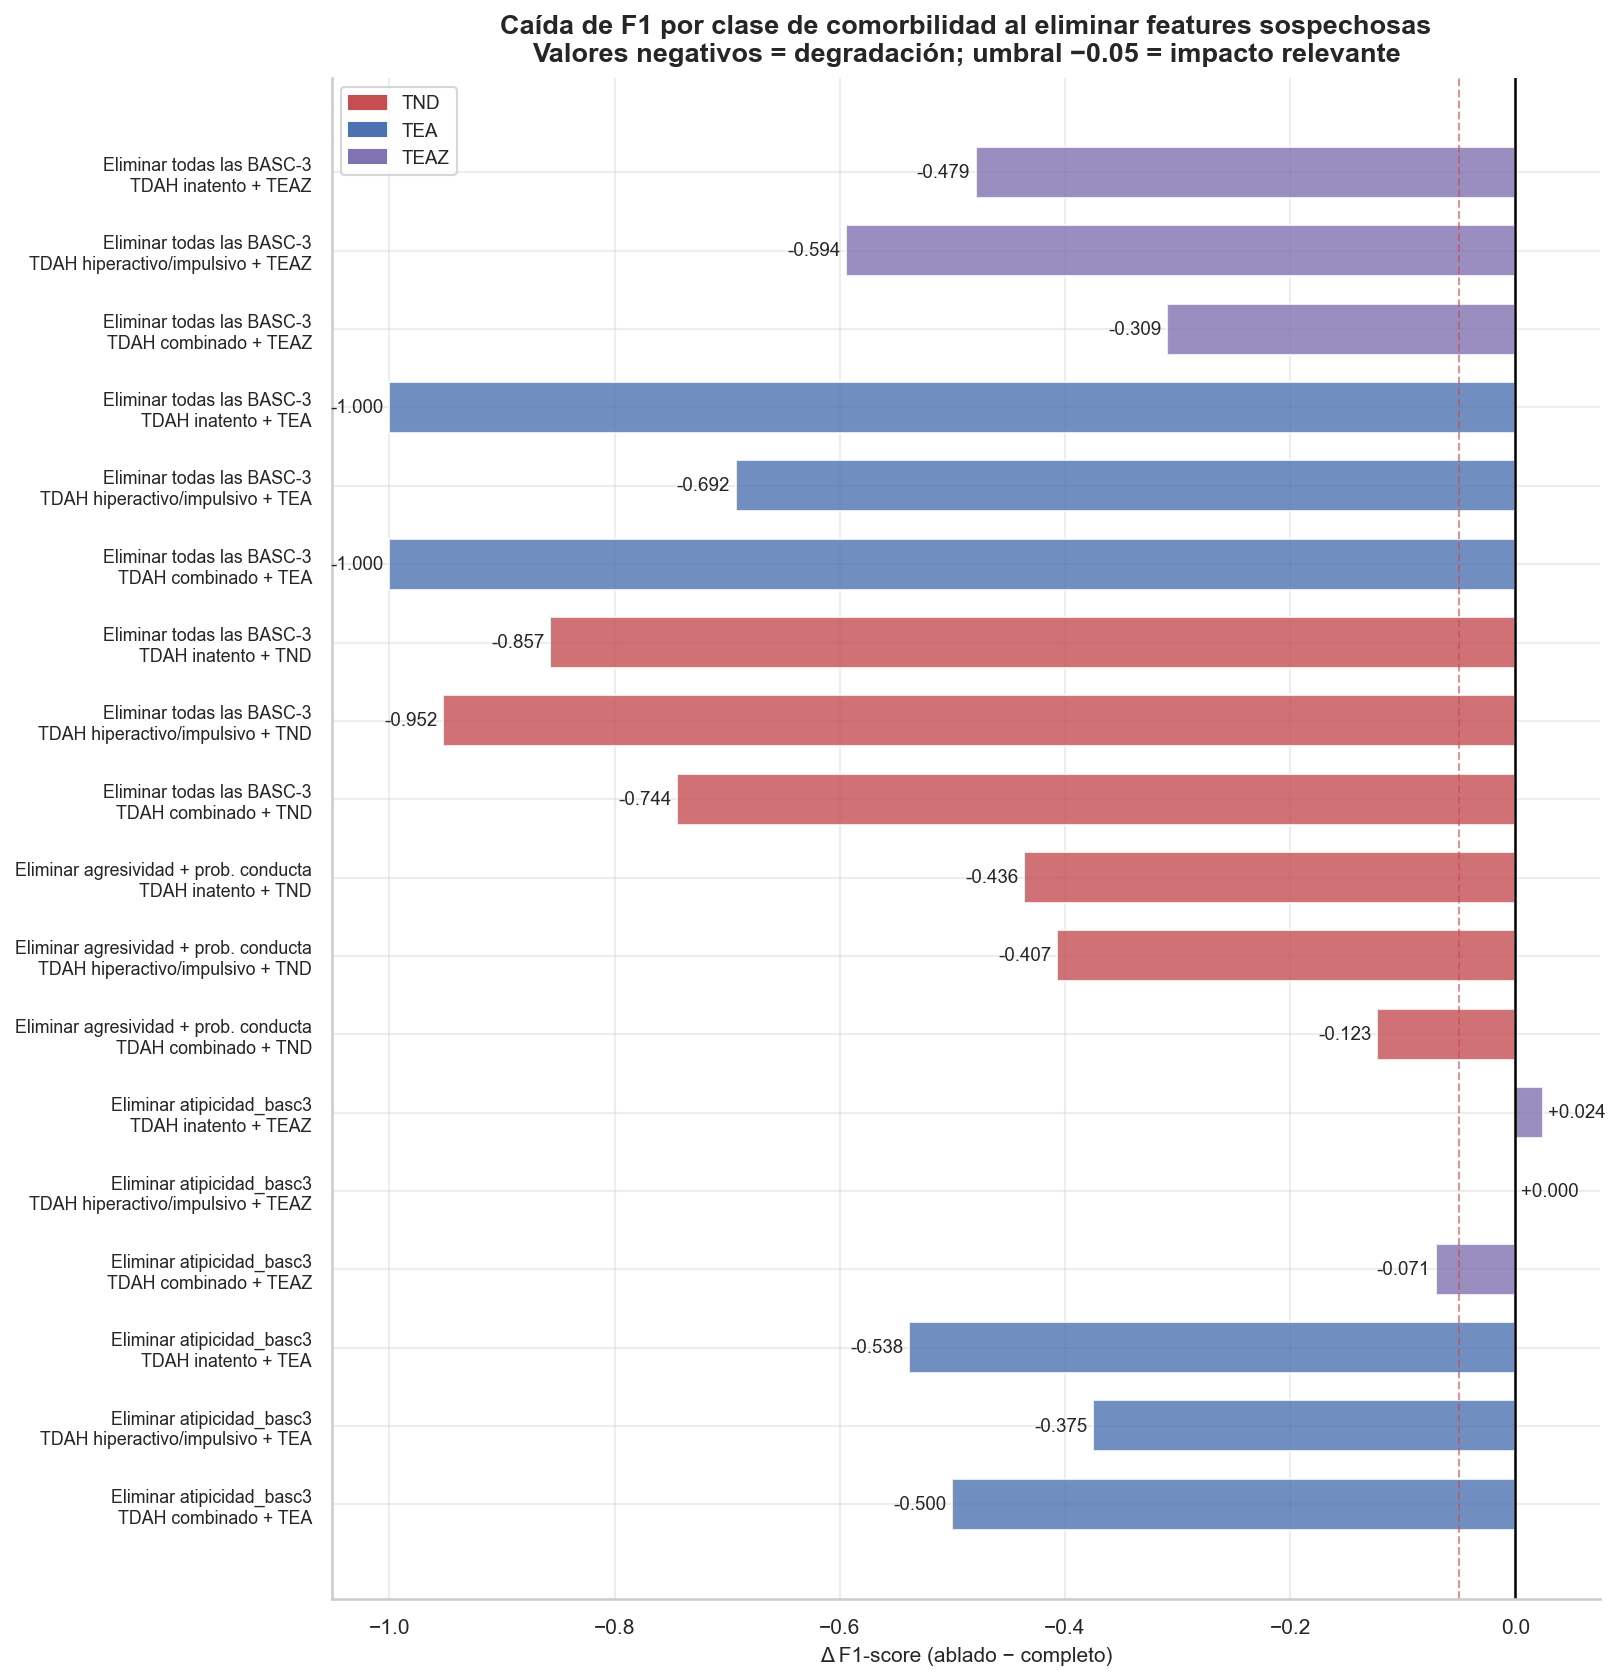

In [19]:
if not drop_df.empty:
    fig, ax = plt.subplots(figsize=(11, max(4, len(drop_df)*0.55 + 1.5)))
    colors_map = {'TND': C_RED, 'TEA': C_BLUE, 'TEAZ': C_PURP}
    for i, row in drop_df.iterrows():
        color = colors_map.get(row['Comorbilidad'], C_GRAY)
        ax.barh(i, row['Delta'], color=color, alpha=0.8, edgecolor='white', height=0.65)
        ax.text(row['Delta'] + (0.005 if row['Delta'] >= 0 else -0.005),
                i, f"{row['Delta']:+.3f}", va='center',
                ha='left' if row['Delta'] >= 0 else 'right', fontsize=9)
    ax.set_yticks(range(len(drop_df)))
    ax.set_yticklabels([f"{r['Ablación']}\n{r['Etiqueta']}" for _,r in drop_df.iterrows()],
                       fontsize=8.5)
    ax.axvline(0, color='black', lw=1.2)
    ax.axvline(-0.05, color=C_RED, lw=1, linestyle='--', alpha=0.6, label='Umbral -0.05')
    ax.set_xlabel('Δ F1-score (ablado − completo)', fontsize=10)
    ax.set_title('Caída de F1 por clase de comorbilidad al eliminar features sospechosas\n'
                 'Valores negativos = degradación; umbral −0.05 = impacto relevante', pad=8)
    patches = [mpatches.Patch(color=c, label=k) for k,c in colors_map.items()]
    ax.legend(handles=patches, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos suficientes para la gráfica de caída.")


📋 **Interpretación — Caída de F1 por comorbilidad**

El umbral de −0.05 en F1 es una referencia operativa: una caída mayor de 5 puntos en las clases de comorbilidad al eliminar la feature sospechosa es señal de dependencia relevante.

**Escenarios de interpretación:**

- **Caída grande y selectiva** (p.ej. TEA/TEAZ cae >0.05 al eliminar atipicidad, pero el resto no): confirma que `atipicidad_basc3` es casi el único discriminador de esas clases → riesgo metodológico alto.

- **Caída uniforme** (todas las clases caen proporcionalmente): la feature contribuye a la discriminación general, no solo a una comorbilidad → menor riesgo de circularidad.

- **Sin caída o caída pequeña** (<0.03): la feature es redundante con otras → el modelo no depende de ella para identificar esa comorbilidad → menor riesgo.

- **F4 (sin BASC-3)**: establece el baseline realista. Si sin BASC-3 el modelo de comorbilidades prácticamente colapsa, confirma que toda la capacidad de 13 clases está en las escalas conductuales.

---
## Bloque 6 — Tabla resumen y veredicto metodológico

In [20]:
# ── Tabla resumen ejecutiva ─────────────────────────────────────────────
summary = []
for name, res in results.items():
    row = {
        'Configuración': name,
        'N features'   : res['n_feats'],
        'CV F1±std'    : f"{res['cv_f1_mean']:.3f}±{res['cv_f1_std']:.3f}",
        'Test F1'      : f"{res['test_f1']:.3f}",
        'Δ vs completo': f"{res['test_f1']-list(results.values())[0]['test_f1']:+.3f}",
    }
    summary.append(row)
sm = pd.DataFrame(summary)
print(sm.to_string(index=False))

print("\n" + "="*65)
full_f1  = list(results.values())[0]['test_f1']
nobasc_key = [k for k in results if 'Sin BASC-3' in k][0]
nobasc_f1  = results[nobasc_key]['test_f1']
delta_basc = nobasc_f1 - full_f1
print(f"  Impacto total BASC-3: {delta_basc:+.3f} en Test F1-macro")
print(f"  ({abs(delta_basc)*100:.1f} puntos {'de caída' if delta_basc < 0 else 'de ganancia'})")
print("="*65)


                      Configuración  N features   CV F1±std Test F1 Δ vs completo
            F1 — Completo (14 vars)          14 0.954±0.016   0.942        +0.000
                F2 — Sin atipicidad          13 0.833±0.045   0.799        -0.143
    F3 — Sin agresividad + conducta          12 0.829±0.031   0.816        -0.126
F4 — Sin BASC-3 (solo cogn.+demog.)           9 0.248±0.039   0.258        -0.684
          F5 — Solo BASC-3 (5 vars)           5 0.874±0.030   0.891        -0.051

  Impacto total BASC-3: -0.684 en Test F1-macro
  (68.4 puntos de caída)


---
### Veredicto metodológico del estudio de ablación

El estudio de ablación responde a la pregunta central con datos cuantitativos: **¿en qué medida el modelo de 13 clases depende de features que se solapan con la definición de las comorbilidades?**

**Interpretación del impacto total BASC-3 (F4 vs F1):**
- Si la caída al eliminar todas las BASC-3 es **> 0.10** en F1-macro: la capacidad de distinguir comorbilidades reside principalmente en las escalas conductuales → dependencia alta → el riesgo metodológico es real y debe declararse explícitamente.
- Si la caída es **0.05–0.10**: las BASC-3 son importantes pero no exclusivas → riesgo moderado → documentar como limitación.
- Si la caída es **< 0.05**: la información demográfica y cognitiva ya captura gran parte de la señal → las BASC-3 son un complemento, no el motor → riesgo bajo.

**Recomendación para el notebook `model_13clases.ipynb`:**
Añadir una sección de limitaciones que declare explícitamente el grado de solapamiento feature-diagnóstico encontrado aquí, y referenciar este notebook como verificación metodológica. Si la caída selectiva para TEA/TEAZ o TND es grande, recomendar que el modelo sea usado como apoyo clínico (no como herramienta de screening independiente), y que la validación externa con otro equipo clínico es condición necesaria antes de cualquier despliegue.

---
*Estudio de ablación — Proyecto EDA-TDAH · Mayo 2026*